In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/ai-2-dl-for-nlp-2025-homework-3-distil-bert/sample_submission.csv
/kaggle/input/ai-2-dl-for-nlp-2025-homework-3-distil-bert/train_dataset.csv
/kaggle/input/ai-2-dl-for-nlp-2025-homework-3-distil-bert/test_dataset.csv
/kaggle/input/ai-2-dl-for-nlp-2025-homework-3-distil-bert/val_dataset.csv


---
# Imports
---


In [2]:
###
### Γεώργιος Σκούρας sdi2100172
###

# (Uncomment to install if needed)
#!pip install transformers datasets 
# !pip install optuna  
# !pip install wordcloud
# !pip install contractions

import os
import random
import numpy as np
import pandas as pd
import torch
from tqdm.auto import tqdm
import torch.nn as nn
import matplotlib.pyplot as plt
import seaborn as sns

from wordcloud import WordCloud
from collections import Counter

# HuggingFace & PyTorch imports
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    get_linear_schedule_with_warmup
)
from transformers.modeling_outputs import SequenceClassifierOutput
from transformers import DistilBertModel
from torch.optim import AdamW
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    roc_curve,
    auc,
    confusion_matrix
)

# Model checkpoint
MODEL_NAME = "distilbert-base-uncased"

#  Reproducibility
RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)
torch.cuda.manual_seed_all(RANDOM_SEED)

#  Device
device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
print(f"Using device: {device}")

#  Tokenizer & model
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
# model     = AutoModelForSequenceClassification.from_pretrained(
#                 MODEL_NAME,
#                 num_labels=2
#             ).to(device)

###
### Γεώργιος Σκούρας sdi2100172
###

2025-06-08 14:09:56.728287: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1749391796.922059      19 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1749391796.984352      19 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


Using device: cuda


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

---
# Basic EDA
---

In [3]:
###
### Taken from project 1 and 2 with adjustments 
###


def generate_wordcloud(text_series, max_words=200, figsize=(12,6)):
    """
    text_series: a pandas Series of raw strings (already preprocessed)
    """
    # Join into one big string
    all_text = " ".join(text_series.tolist())
    wc = WordCloud(width=800, height=400, background_color="white",
                   max_words=max_words).generate(all_text)
    plt.figure(figsize=figsize)
    plt.imshow(wc, interpolation="bilinear")
    plt.axis("off")
    plt.title("Word Cloud of Preprocessed Text")
    plt.show()

def plot_token_frequency(text_series, top_n=20, figsize=(12,6)):
    """
    text_series: a pandas Series of raw strings (already preprocessed)
    """
    # Split into tokens
    tokens = " ".join(text_series.tolist()).split()
    freq   = Counter(tokens)
    common = freq.most_common(top_n)
    words, counts = zip(*common)
    
    plt.figure(figsize=figsize)
    plt.bar(range(len(words)), counts, tick_label=words , color='skyblue')
    plt.xticks(rotation=45, ha="right")
    plt.xlabel('Tokens')
    plt.title(f"Top {top_n} Token Frequencies")
    plt.ylabel("Frequency")
    plt.tight_layout()
    plt.show()


Train samples: 148388
       ID                                               Text  Label
0  189385      @whoisralphie dude  I'm so bummed ur leaving!      0
1   58036  oh my god, a severed foot was foun in a wheely...      0
2  190139  I end up &quot;dog dialing&quot; sumtimes. Wha...      1
3   99313                         @_rachelx meeeee toooooo!       0
4  157825  I was hoping I could stay home and work today,...      0 

Train class balance:
 Label
1    74196
0    74192
Name: count, dtype: int64 



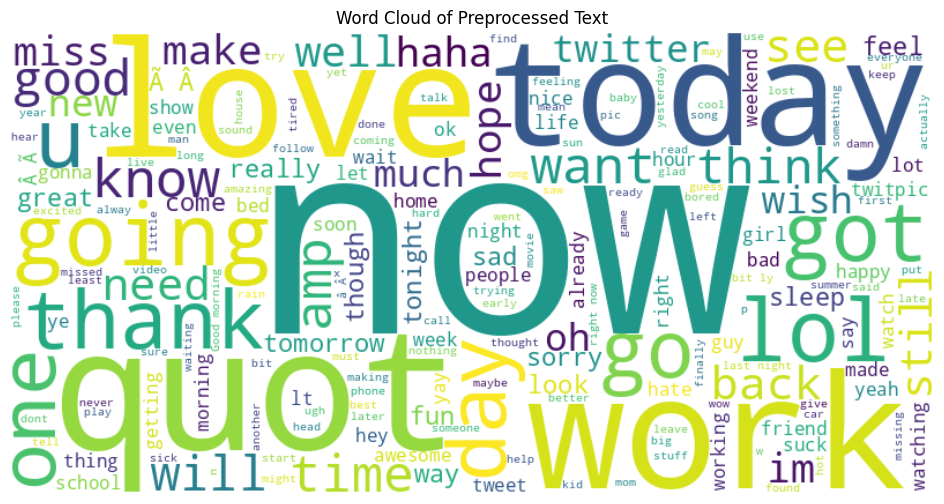

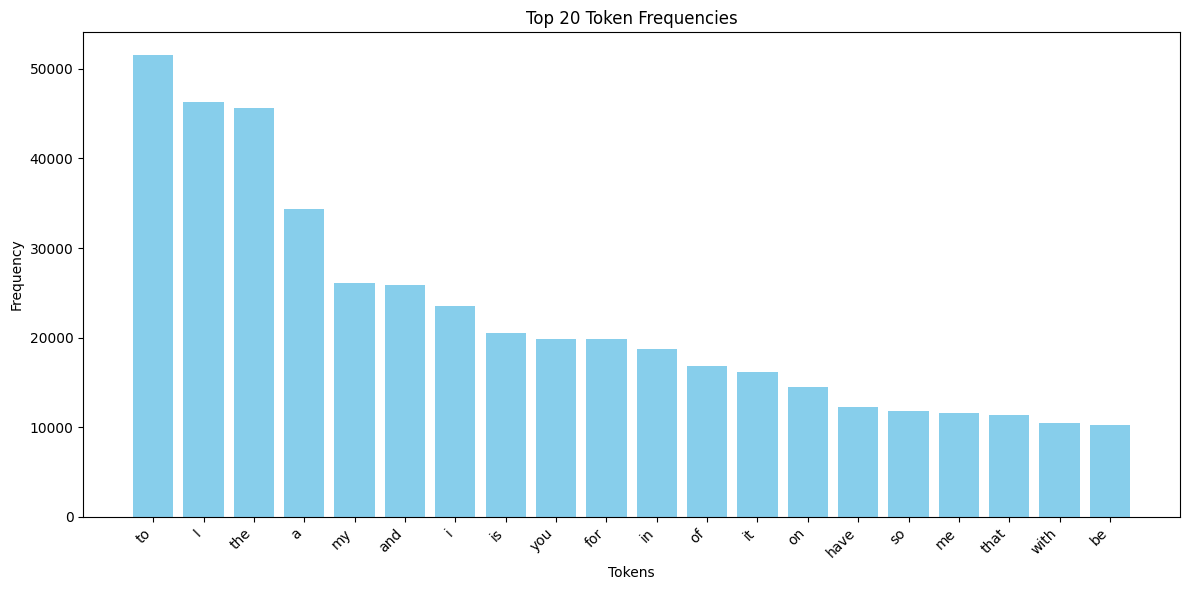

Batches ➔ train: 4638, val: 1325, test: 663


In [4]:
#Read CSVs
train_df = pd.read_csv("/kaggle/input/ai-2-dl-for-nlp-2025-homework-3-distil-bert/train_dataset.csv")
val_df   = pd.read_csv("/kaggle/input/ai-2-dl-for-nlp-2025-homework-3-distil-bert/val_dataset.csv")
test_df  = pd.read_csv("/kaggle/input/ai-2-dl-for-nlp-2025-homework-3-distil-bert/test_dataset.csv")

#  Inspect and preview the first few rows
print(f"Train samples: {len(train_df)}")
print(train_df.head(), "\n")
print("Train class balance:\n", train_df['Label'].value_counts(), "\n")

generate_wordcloud(train_df['Text']) # Visual summary of most common words
plot_token_frequency(train_df['Text']) # Bar chart of top tokens by frequency

# PyTorch-compatible dataset for sentiment classification using DistilBERT
class SentimentDataset(Dataset):
    def __init__(self, df, tokenizer, max_len=128, is_test=False):
        self.texts = df['Text'].tolist()  # List of text samples
        self.labels = None if is_test else df['Label'].tolist() # Labels (only for train/val)
        self.tokenizer = tokenizer
        self.max_len = max_len
        self.is_test = is_test

    def __len__(self):
        return len(self.texts)
        
     # Get the raw text at the given index
    def __getitem__(self, idx):
        text = self.texts[idx]
        enc = self.tokenizer.encode_plus( # Tokenize the input text
            text,
            add_special_tokens=True,
            max_length=self.max_len,
            padding='max_length',
            truncation=True,
            return_attention_mask=True,
            return_tensors='pt'
        )
        # Format as a dictionary with necessary inputs
        item = {
            'input_ids':      enc['input_ids'].squeeze(0),
            'attention_mask': enc['attention_mask'].squeeze(0),
        }
        # But add label only if it's not a test sample
        if not self.is_test:
            item['labels'] = torch.tensor(self.labels[idx], dtype=torch.long)
        return item

# Datasets & loaders
BATCH_SIZE = 32

# Create dataset objects for training, validation, and test
train_ds = SentimentDataset(train_df, tokenizer)
val_ds   = SentimentDataset(val_df,   tokenizer)
test_ds  = SentimentDataset(test_df,  tokenizer, is_test=True)

# Create data loaders to efficiently feed data into the model
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE)

print(f"Batches ➔ train: {len(train_loader)}, val: {len(val_loader)}, test: {len(test_loader)}")

---
# DistilBert Classifier
---

In [5]:
class DistilBERTClassifier(nn.Module):
    def __init__(
        self,
        model_name="distilbert-base-uncased",   # Pretrained DistilBERT model name
        hidden_dim=512, # Hidden dimension for the classifier head
        num_labels=2,   # We're doing binary classification 
        dropout_prob=0.2   # Dropout probability for regularization
    ):
        super().__init__()
        self.distilbert = DistilBertModel.from_pretrained(model_name)
        self.classifier = nn.Sequential(
            nn.Dropout(dropout_prob),
            nn.Linear(self.distilbert.config.hidden_size, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout_prob),
            nn.Linear(hidden_dim, num_labels)
        )

    def forward(self, input_ids, attention_mask, labels=None):
          # Pass inputs through DistilBERT
        outputs = self.distilbert(input_ids=input_ids, attention_mask=attention_mask)
        cls_output = outputs.last_hidden_state[:, 0, :] # Extract the CLS embedding
        # Pass through our classifier head to get the final logits (raw predictions)
        logits = self.classifier(cls_output)

        # If we have labels, calculate the classification loss (used during training)
        loss = None
        if labels is not None:
            loss_fn = nn.CrossEntropyLoss()
            loss = loss_fn(logits, labels)

        # Return loss (if any) and logits
        return SequenceClassifierOutput(loss=loss, logits=logits)

model = DistilBERTClassifier().to(device)

Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

In [6]:
###
### Taken from project 1 and 2 with adjustments 
###


# ---- Plotting Functions ----

def plot_roc_curve(model, dataloader):
    model.eval()
    all_probs = []
    all_labels = []
    with torch.no_grad():
        for batch in dataloader:
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["labels"].to(device)
            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            probs = torch.softmax(outputs.logits, dim=1)[:, 1]
            all_probs.extend(probs.cpu().tolist())
            all_labels.extend(labels.cpu().tolist())
    fpr, tpr, _ = roc_curve(all_labels, all_probs)
    roc_auc = auc(fpr, tpr)
    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, color='#1f77b4', lw=2, label=f'ROC curve (AUC = {roc_auc:.3f})')
    plt.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curve')
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

def plot_confusion_matrix(model, dataloader):
    model.eval()
    all_preds = []
    all_labels = []
    with torch.no_grad():
        for batch in dataloader:
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["labels"].to(device)
            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            probs = torch.softmax(outputs.logits, dim=1)[:, 1]
            preds = (probs >= 0.5).int()
            all_preds.extend(preds.cpu().tolist())
            all_labels.extend(labels.cpu().tolist())
    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False, linewidths=1, linecolor='black')
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.title("Confusion Matrix")
    plt.show()

def plot_learning_curve(train_losses, val_losses):
    epochs = range(1, len(train_losses) + 1)
    plt.figure(figsize=(8, 6))
    plt.plot(epochs, train_losses, label='Train Loss', marker='o')
    plt.plot(epochs, val_losses, label='Validation Loss', marker='o')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Learning Curve')
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

---
# Training  Model
---


=== Epoch 1/3 ===


Training:   0%|          | 0/4638 [00:00<?, ?it/s]

Train • loss 0.4172 | acc 0.8040 | prec 0.7954 | rec 0.8187 | F1 0.8068


Validating:   0%|          | 0/1325 [00:00<?, ?it/s]

Val   • loss 0.3608 | acc 0.8407 | prec 0.8574 | rec 0.8175 | F1 0.8370
✅ Saved best model

=== Epoch 2/3 ===


...

Val   • loss 0.3596 | acc 0.8470 | prec 0.8533 | rec 0.8382 | F1 0.8457
✅ Saved best model

=== Epoch 3/3 ===


Training:   0%|          | 0/4638 [00:00<?, ?it/s]

Train • loss 0.2408 | acc 0.9031 | prec 0.9057 | rec 0.9000 | F1 0.9028


Validating:   0%|          | 0/1325 [00:00<?, ?it/s]

Val   • loss 0.3897 | acc 0.8468 | prec 0.8478 | rec 0.8454 | F1 0.8466

🏁 Best Val Accuracy: 0.8470


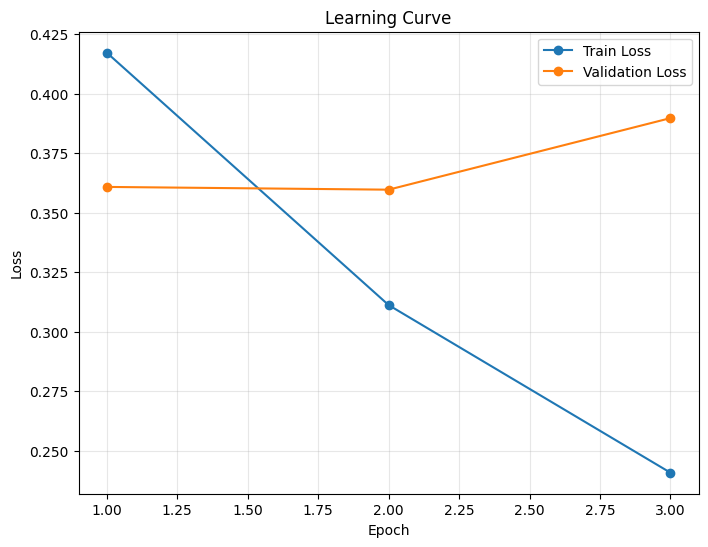

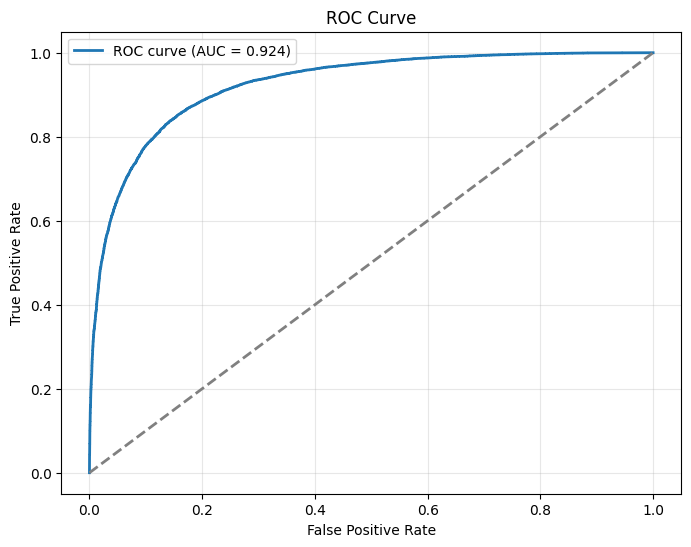

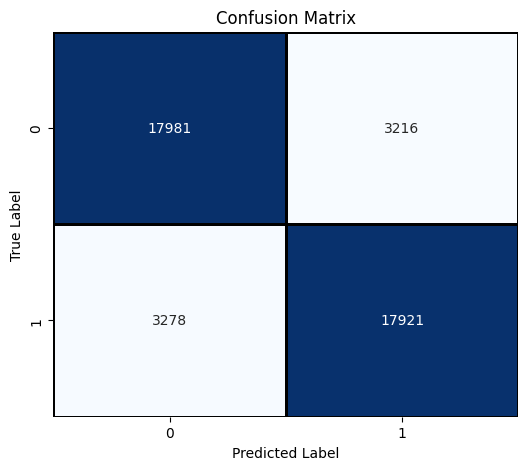

In [7]:


# Parameters
EPOCHS        = 3     # Number of passes through the training data
LEARNING_RATE = 2e-5  # How big each update step is (too big = unstable, too small = slow)
EPS           = 1e-8  # Small value to prevent division by 0 in Adam optimizer
WEIGHT_DECAY  = 0.01  # Regularization to prevent overfitting

# Optimizer & scheduler
optimizer = AdamW( model.parameters(), lr=LEARNING_RATE, eps=EPS, weight_decay=WEIGHT_DECAY)
# Total number of batches across all epochs
total_steps = len(train_loader) * EPOCHS
# Scheduler gradually increases then decreases the learning rate
scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps   = int(0.1 * total_steps), # 10% steps
    num_training_steps = total_steps
)

# Track losses for plotting later
train_losses_all = []
val_losses_all = []

#Training function

def train_model(model, train_loader, val_loader, optimizer, scheduler, epochs=3, save_path="best_distilbert.pt"):
    best_val_acc = 0.0 # Track best validation accuracy so we can save the best mode

    for epoch in range(1, epochs + 1):
        print(f"\n=== Epoch {epoch}/{epochs} ===")
        model.train()  # Set to training mode
        epoch_train_losses = []
        train_preds, train_labels = [], []

        for batch in tqdm(train_loader, desc="Training", leave=False):
            inputs = { # A check
                "input_ids": batch["input_ids"].to(device),
                "attention_mask": batch["attention_mask"].to(device),
                "labels": batch["labels"].to(device)
            }

            outputs = model(**inputs)
            loss = outputs.loss
            logits = outputs.logits

            optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            scheduler.step()

            # Track loss and predictions for training metrics
            epoch_train_losses.append(loss.item())
            preds = logits.argmax(dim=1).cpu().numpy()
            labels = inputs["labels"].cpu().numpy()
            train_preds.extend(preds)
            train_labels.extend(labels)

         # Compute training metrics
        avg_train_loss = np.mean(epoch_train_losses)
        train_losses_all.append(avg_train_loss)
        train_acc = accuracy_score(train_labels, train_preds)
        train_prec, train_rec, train_f1, _ = precision_recall_fscore_support(train_labels, train_preds, average='binary')
        print(f"Train • loss {avg_train_loss:.4f} | acc {train_acc:.4f} | prec {train_prec:.4f} | rec {train_rec:.4f} | F1 {train_f1:.4f}")

        model.eval()
        epoch_val_losses = []
        val_preds, val_labels = [], []

        with torch.no_grad():
            for batch in tqdm(val_loader, desc="Validating", leave=False):
                inputs = {
                    "input_ids": batch["input_ids"].to(device),
                    "attention_mask": batch["attention_mask"].to(device),
                    "labels": batch["labels"].to(device)
                }

                outputs = model(**inputs)
                epoch_val_losses.append(outputs.loss.item())
                preds = outputs.logits.argmax(dim=1).cpu().numpy()
                val_preds.extend(preds)
                val_labels.extend(batch["labels"].cpu().numpy())

        # Compute validation metrics
        avg_val_loss = np.mean(epoch_val_losses)
        val_losses_all.append(avg_val_loss)
        val_acc = accuracy_score(val_labels, val_preds)
        val_prec, val_rec, val_f1, _ = precision_recall_fscore_support(val_labels, val_preds, average='binary')
        
        print(f"Val   • loss {avg_val_loss:.4f} | acc {val_acc:.4f} | prec {val_prec:.4f} | rec {val_rec:.4f} | F1 {val_f1:.4f}")
        
        # Save the model if this is the best so far
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save(model.state_dict(), save_path)
            print("✅ Saved best model")

    print(f"\n🏁 Best Val Accuracy: {best_val_acc:.4f}")

# Run training
train_model(model, 
            train_loader, 
            val_loader, 
            optimizer, 
            scheduler, 
            epochs=EPOCHS,
            save_path="best_distilbert.pt"
)
# ---- Post‐training plots ----
plot_learning_curve(train_losses_all, val_losses_all)
plot_roc_curve(model, val_loader)
plot_confusion_matrix(model, val_loader)

---
# Submission
---

In [8]:

# Reload best weights
model.load_state_dict(torch.load("best_distilbert.pt"))
model.to(device)
model.eval()

# Make predictions on the test set (no labels)
test_preds = []
with torch.no_grad():
    for batch in test_loader:
        inputs = {k: v.to(device) for k, v in batch.items()}
        logits = model(**inputs).logits
        test_preds.extend(logits.argmax(dim=1).cpu().numpy())

# Build & save submission
submission = pd.DataFrame({
    "ID":    test_df["ID"],
    "Label": test_preds
})
print(submission.head())
submission.to_csv("submission.csv", index=False)
print("✅ Submission saved as distilbert_submission.csv")

/tmp/ipykernel_19/1262597142.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("best_distilbert.pt"))


       ID  Label
0  102388      1
1  153802      0
2   61831      0
3   18317      1
4   50061      1
✅ Submission saved as distilbert_submission.csv
